In [1]:
from ase.optimize import FIRE  
import numpy as np
from pathlib import Path
import csv


## Other default imports 

In [2]:
import os, re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
# from pymatgen.ext.matproj import MPRester
from mp_api.client import MPRester
from pymatgen.core import Composition, Element
from pymatgen.analysis.phase_diagram import GrandPotentialPhaseDiagram, PhaseDiagram
from pymatgen.analysis.interface_reactions import InterfacialReactivity, GrandPotentialInterfacialReactivity
from emmet.core.thermo import ThermoType
from pymatgen.entries.computed_entries import ComputedEntry
from matplotlib.patches import Patch
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from pathlib import Path



In [3]:
%%capture
import siman #program package to manage DFT calculations https://github.com/dimonaks/siman
from siman.calc_manage import smart_structure_read, get_structure_from_matproj, get_structure_from_matproj_new
from siman.calc_manage import add, res
# Update configurations
from siman import header
from siman.database import write_database, read_database
from siman.set_functions import read_vasp_sets
from siman.header import db
from siman.header import _update_configuration
_update_configuration('project_conf.py')
read_database() # read saved database if available
from pydoc import importfile
project_sets = importfile('project_sets.py')
varset = read_vasp_sets(project_sets.user_vasp_sets, override_global = 0) #read user sets

from siman import thermo

# header.PATH2PROJECT = '../dft_calculations/'
header.PATH2EDITOR = 'notepad.exe'
header.PATH2POTENTIALS = "/home/a.burov/soft/vasp_potentials/potpaw_PBE_MPIE/"

from matplotlib import rc



In [4]:
from ase.optimize import FIRE  
from ase.io import read, write
from ase.visualize import view


In [5]:
from matplotlib import font_manager as fm
font_path = "/home/a.burov/fonts/ARIAL.TTF"
fm.fontManager.addfont(font_path)


In [6]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [7]:
np.set_printoptions(precision=5)


In [8]:
# %matplotlib inline
plt.rcParams['figure.dpi'] = 450


In [9]:
API_KEY = "LTSM6dStBrl69FjopxP7KdZBP35B1yh7"

## DFT Calculations

### Layered

In [10]:
def generate_substitutions(struct):
    """Generate all F ↔ O-H exchange configurations"""
    configs = []
    
    # Identify anion sites (O=8-11, F=12-15)
    O_sites = [8, 9, 10, 11]
    F_sites = [12, 13, 14, 15]
    
    from itertools import combinations
    
    # All possible exchanges (1:1 substitution)
    for n_sub in range(1, 5):  # 1 to 4 exchanges
        for f_idx in combinations(F_sites, n_sub):
            for o_idx in combinations(O_sites, n_sub):
                new_struct = struct.copy()
                
                # Exchange: F → O, O → F at selected sites
                for i, j in zip(f_idx, o_idx):
                    new_struct.replace(i, "O")   # F site → O
                    new_struct.replace(j, "F")   # O site → F
                
                # Check uniqueness (avoid duplicates)
                new_struct.get_sorted_structure()
                configs.append(new_struct)
    
    return configs



In [67]:
st_layered = smart_structure_read("/home/a.burov/icys_2025/niohf/initial_no_relaxation/CuOHF.cif")

In [68]:
st_layered.printme()

Full Formula (Cu4 H4 O4 F4)
Reduced Formula: CuHOF
abc   :   5.301000   6.376000   5.074000
angles:  90.000000 112.900000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP          a        b        c
---  ----  -------  -------  -------
  0  Cu    0.75725  0.3775   0.99112
  1  Cu    0.74275  0.8775   0.00888
  2  Cu    0.24275  0.6225   0.00888
  3  Cu    0.25725  0.1225   0.99112
  4  H     0.698    0.131    0.337
  5  H     0.802    0.631    0.663
  6  H     0.302    0.869    0.663
  7  H     0.198    0.369    0.337
  8  O     0.6611   0.13548  0.1783
  9  O     0.8389   0.63548  0.8217
 10  O     0.3389   0.86452  0.8217
 11  O     0.1611   0.36452  0.1783
 12  F     0.8721   0.11643  0.7381
 13  F     0.6279   0.61643  0.2619
 14  F     0.1279   0.88357  0.2619
 15  F     0.3721   0.38357  0.7381


In [69]:
st_pmg = st_layered.convert2pymatgen()

In [18]:
new_configs = generate_substitutions(st_pmg)
print(f"Generated {len(new_configs)} configurations")


Generated 69 configurations


In [19]:
from pymatgen.analysis.structure_matcher import StructureMatcher
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

In [20]:
def aggressive_filter(configs):
    """Reduce 69 → 5-10 unique structures (fixed API)"""
    unique = []
    
    for config in configs:
        # 1. Niggli reduction
        reduced = config.get_reduced_structure(reduction_algo="niggli")
        
        # 2. Skip if already in unique list
        is_duplicate = False
        for u in unique:
            u_reduced = u.get_reduced_structure(reduction_algo="niggli")
            
            # Fixed: rmsd_cutoff instead of tolerance
            matcher = StructureMatcher(
                primitive_cell=True, 
                # scale=True,
                scale=False, 
                ltol=0.3,  
                stol=0.5,
                angle_tol=5,
                attempt_supercell=False
            )
            if matcher.fit(reduced, u_reduced):
                is_duplicate = True
                break
        
        if not is_duplicate:
            unique.append(config)
    
    return unique


In [21]:
def fast_symmetry_filter(configs):
    """Ultra-fast symmetry reduction using spacegroup"""
    seen = {}
    unique = []
    
    for i, config in enumerate(configs):
        sg = SpacegroupAnalyzer(config)
        sg_key = sg.get_space_group_symbol()
        formula = config.formula
        
        key = f"{formula}_{sg_key}"
        
        if key not in seen:
            seen[key] = True
            unique.append(config)
            print(f"Added: {formula} | {sg_key}")
    
    return unique

In [22]:
unique_configs = fast_symmetry_filter(new_configs)
print(f"Unique by symmetry: {len(unique_configs)}")


Added: Cu4 H4 O4 F4 | P1
Added: Cu4 H4 O4 F4 | P2_1
Added: Cu4 H4 O4 F4 | P-1
Added: Cu4 H4 O4 F4 | Pc
Added: Cu4 H4 O4 F4 | P2_1/c
Unique by symmetry: 5


In [23]:
from siman.core.structure import Structure as base_siman_structure

In [29]:
for st_refined in unique_configs:
    sp_gr = st_refined.get_symmetry_dataset()['international']
    sp_gr = sp_gr.replace("/", "_")
    st_siman = base_siman_structure().update_from_pymatgen(stpm=st_refined)

    els = st_siman.get_elements()
    els_ni = [idx for idx, el in enumerate(els) if el == "Cu"]
    st_siman = st_siman.replace_atoms(els_ni, "Ni")

    print(st_siman.get_formula(), sp_gr)

    if 0:
        st_siman.write_poscar(f"/home/a.burov/icys_2025/niohf/initial_no_relaxation/layered/layered_{sp_gr}.POSCAR")
        st_siman.write_cif(f"/home/a.burov/icys_2025/niohf/initial_no_relaxation/layered/layered_{sp_gr}")

    # add(f"layered_{sp_gr}", '9bulk_eos', 1, it_folder = 'layered', input_st = st_siman, calc_method = 'c_scale', 
				# n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128_zen', up='up2', run=2)
    # add(f"layered_{sp_gr}", '9bulk_eos', 1, it_folder = 'layered', input_st = st_siman, calc_method = 'uniform_scale', 
				# n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)
    # add(f"layered_{sp_gr}", '9bulk', 1, it_folder = 'layered', input_st = st_siman, cluster = 'razor128', up='up2', run=2)

    # res(f"layered_{sp_gr}.sc", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    # res(f"layered_{sp_gr}.su", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    # res(f"layered_{sp_gr}", '9bulk', 1, cluster = 'razor128', )

    st = db[f"layered_{sp_gr}", '9bulk', 1].copy().end
    # add(f"layered_{sp_gr}_rel", '9bulk_eos', 1, it_folder = 'layered', input_st = st, calc_method = 'c_scale', 
				# n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)
    # add(f"layered_{sp_gr}_rel", '9bulk_eos', 1, it_folder = 'layered', input_st = st, calc_method = 'uniform_scale', 
				# n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)
    
    # res(f"layered_{sp_gr}_rel.sc", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    # res(f"layered_{sp_gr}_rel.su", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')

    st = db[f"layered_{sp_gr}_rel.sc", '9bulk_eos', 100].copy().end
    # add(f"layered_{sp_gr}_final", '9bulk', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final", '9bulk', 1, cluster = 'razor128', up='up2', )

    # check calcs
    # add(f"layered_{sp_gr}_final", '9bulk_fine', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final", '9bulk_fine', 1, cluster = 'razor128', up='up2', )

    # add(f"layered_{sp_gr}_final_su", '9bulk_fine_vdw', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final_su", '9bulk_fine_vdw', 1, cluster = 'razor128', up='up2', )

    # add(f"layered_{sp_gr}_final_su", '9bulk_fine_rel_vdw', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final_su", '9bulk_fine_rel_vdw', 1, cluster = 'razor128', up='up2', )
    
    # st = db[f"layered_{sp_gr}_rel.su", '9bulk_eos', 100].copy().end
    # add(f"layered_{sp_gr}_final_su", '9bulk', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final_su", '9bulk', 1, cluster = 'razor128', up='up2', )

    # add(f"layered_{sp_gr}_final_su", '9bulk_fine', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final_su", '9bulk_fine', 1, cluster = 'razor128', up='up2', )

    # add(f"layered_{sp_gr}_final_su", '9bulk_fine_rel', 1, it_folder = 'layered', input_st = st, cluster = 'razor128', up='up2', run=2)
    # res(f"layered_{sp_gr}_final_su", '9bulk_fine_rel', 1, cluster = 'razor128', up='up2', )

    # db[f"layered_{sp_gr}.sc", '9bulk_eos', 100].run("9bulk_cell", run=2, add=2, cluster = 'razor128_zen')
    # db[f"layered_{sp_gr}.sc.ifn", '9bulk_cell', 100].res(up="up2", cluster = 'razor128_zen')
    

Ni4 H4 O4 F4 P1
Ni4 H4 O4 F4 P2_1
Ni4 H4 O4 F4 P-1
Ni4 H4 O4 F4 Pc
Ni4 H4 O4 F4 P2_1_c


In [30]:
write_database()


Database has been successfully updated



In [31]:
els = st_layered.get_elements()
els_ni = [idx for idx, el in enumerate(els) if el == "Cu"]

In [32]:
st_layered = st_layered.replace_atoms(els_ni, "Ni")

In [33]:
# add("layered", '9bulk_eos', 1, it_folder = 'layered', input_st = st_layered, calc_method = 'c_scale', 
# 				n_scale_images=10, scale_region = (-5, 5), cluster = 'razor128', up='up2', run=2)

# res("layered.sc", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', 
#         up="up2", cluster = 'razor128')


In [34]:
st_rel = db["layered.sc", '9bulk_eos', 100].copy().end


In [35]:
# add("layered", '9bulk', 1, it_folder = 'layered', input_st = st_rel, cluster = 'razor128', up='up2', run=2)


In [36]:
# res("layered", '9bulk', 1, cluster = 'razor128', )


### Layered, DFT-D3 EOS

Same volume setup as `9bulk_eos`: DFT-D3 (`IVDW=11`), `ISIF=4`, DFT+U off, 10 `c_scale` images over ±10%. Set name is `9bulk_eos_vdw` so these jobs stay separate from the existing EOS entries. Uncomment `add` to submit, then `res` after they finish.

In [37]:
layered_groups_vdw = ["P1", "P2_1", "P-1", "Pc", "P2_1_c"]

layered_poscar = "/home/a.burov/icys_2025/niohf/initial_no_relaxation/layered"

for sp_gr in layered_groups_vdw:
    st_siman = smart_structure_read(f"{layered_poscar}/layered_{sp_gr}.POSCAR")
    print(st_siman.get_formula(), sp_gr)

    # add(f"layered_{sp_gr}", "9bulk_eos_vdw", 1, it_folder="layered", input_st=st_siman,
    #     calc_method="c_scale", n_scale_images=10, scale_region=(-10, 10),
    #     cluster="razor128_zen", up="up2", run=2)
    
    # res(f"layered_{sp_gr}.sc", "9bulk_eos_vdw", list(range(1, 11)) + [100],
    #     show="fit", analys_type="fit_a", up="up2", cluster="razor128")


    # db[f"layered_{sp_gr}.sc", '9bulk_eos_vdw', 100].run("9bulk_cell_vdw", run=2, add=2, cluster='razor128_zen')
    # db[f"layered_{sp_gr}.sc.ifn", '9bulk_cell_vdw', 100].res(up="up2", cluster='razor128')


Ni4 H4 O4 F4 P1
Ni4 H4 O4 F4 P2_1
Ni4 H4 O4 F4 P-1
Ni4 H4 O4 F4 Pc
Ni4 H4 O4 F4 P2_1_c


In [38]:
write_database()



Database has been successfully updated



### Diaspore

In [12]:
st_alpha = smart_structure_read("/home/a.burov/icys_2025/niohf/initial_no_relaxation/diaspore_NiOHF_alpha.POSCAR")
st_beta = smart_structure_read("/home/a.burov/icys_2025/niohf/initial_no_relaxation/diaspore_NiOHF_beta.POSCAR")
st_gamma = smart_structure_read("/home/a.burov/icys_2025/niohf/initial_no_relaxation/diaspore_NiOHF_gamma.POSCAR")
st_delta = smart_structure_read("/home/a.burov/icys_2025/niohf/initial_no_relaxation/diaspore_NiOHF_delta.POSCAR")


In [13]:
st_list = [
    st_alpha, 
    st_beta, 
    st_gamma, 
    st_delta, 
]


In [14]:
# add("alpha", '9bulk_eos', 1, it_folder = 'diaspore', input_st = st_alpha, calc_method = 'c_scale', 
# 				n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)


In [15]:
# add("beta", '9bulk_eos', 1, it_folder = 'diaspore', input_st = st_beta, calc_method = 'c_scale', 
# 				n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)


In [16]:
# add("gamma", '9bulk_eos', 1, it_folder = 'diaspore', input_st = st_gamma, calc_method = 'c_scale', 
# 				n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)


In [17]:
# add("delta", '9bulk_eos', 1, it_folder = 'diaspore', input_st = st_delta, calc_method = 'c_scale', 
# 				n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128', up='up2', run=2)


In [18]:
st_names = ["alpha", "beta", "gamma", "delta"]

In [19]:
for st_name, st_cur in zip(st_names, st_list):
    st = st_cur.copy()
    st_cur = st_name
    # print(st_cur)
    # add(st_cur, '9bulk_eos', 1, it_folder = 'diaspore', input_st = st, calc_method = 'uniform_scale', 
				# n_scale_images=10, scale_region = (-10, 10), cluster = 'razor128_zen', up='up2', run=2)
    # res(f"{st_name}.su", "9bulk_eos", list(range(1, 11)) + [100], show="fit", analys_type="fit_a", up="up2", cluster="razor128")
    
    # db[f"{st_name}.su", "9bulk_eos", 100].run("9bulk_cell", run=2, add=2, cluster="razor128_zen")
    # db[f"{st_name}.su.ifn", "9bulk_cell", 100].res(cluster="razor128_zen")
    
    

In [20]:
write_database()


Database has been successfully updated



### Diaspore, PBEsol EOS

Same volume setup as `9bulk_eos`: `ISIF=4`, DFT+U off, 10 `c_scale` images over ±10%. Functional is PBEsol (`GGA=PS`) on the PBE PAW potentials, without DFT-D3. Set name is `9bulk_eos_pbesol`. Uncomment `add` to submit, then `res` after they finish.

In [21]:
diaspore_pbesol = {
    "alpha": st_alpha,
    "beta": st_beta,
    "gamma": st_gamma,
    "delta": st_delta,
}


In [36]:
for st_name, st_siman in diaspore_pbesol.items():
    print(st_siman.get_formula(), st_name)

    # add(f"{st_name}", "9bulk_eos", 1, it_folder="diaspore", input_st=st_siman,
    #     calc_method="uniform_scale", n_scale_images=10, scale_region=(-10, 10),
    #     cluster="razor128_zen", up="up2", run=2)

    # add(f"{st_name}", "9bulk_eos_pbesol", 1, it_folder="diaspore", input_st=st_siman,
    #     calc_method="uniform_scale", n_scale_images=10, scale_region=(-10, 10),
    #     cluster="razor128_zen", up="up2", run=2)

    # res(f"{st_name}.su", "9bulk_eos_pbesol", list(range(1, 11)) + [100],
    #     show="fit", analys_type="fit_a", up="up2", cluster="razor128")

    # res(f"{st_name}.su", "9bulk_eos", list(range(1, 11)) + [100],
    #     show="fit", analys_type="fit_a", up="up2", cluster="razor128")

    st = db[f"{st_name}.su", "9bulk_eos", 100].end
    # add(st_name+"_cell", "9bulk_cell", 1, it_folder="diaspore", input_st=st, up="up2", run=2, cluster="razor128_zen")
    # db[st_name+"_cell", "9bulk_cell", 1].res(up="up2", cluster='razor128_zen')

    st = db[f"{st_name}.su", "9bulk_eos_pbesol", 100].end
    # add(st_name+"_cell", "9bulk_cell_pbesol", 1, it_folder="diaspore", input_st=st, up="up2", run=2, cluster="razor128_zen")
    # db[st_name+"_cell", "9bulk_cell_pbesol", 1].res(up="up2", cluster='razor128_zen')


Ni4 H4 O4 F4 alpha
Ni4 H4 O4 F4 beta
Ni4 H4 O4 F4 gamma
Ni4 H4 O4 F4 delta


In [37]:
write_database()


Database has been successfully updated



### Optimized lattice constants

EOS minimum (version 100) after the same 10-point `c_scale` fit.

- Layered: `9bulk_eos` (PBE) vs `9bulk_eos_vdw` (PBE+DFT-D3)
- Diaspore: `9bulk_eos` (PBE) vs `9bulk_eos_pbesol` (PBEsol)

In [38]:
def _lattice_abc(st):
    """Return a, b, c (Å) and cell volume (Å³)."""
    a, b, c = st.rprimd_len()
    r = np.asarray(st.rprimd, dtype=float)
    vol = float(getattr(st, "vol", None) or abs(np.linalg.det(r)))
    return np.array([a, b, c], dtype=float), vol


def _eos_end(*key):
    if key not in db:
        print(f"  missing {key}")
        return None
    return db[key].copy().end


def compare_eos_lattices(pairs, label_a, label_b):
    """pairs: [(name, key_a, key_b), ...]. Print a,b,c and the percent change b vs a."""
    rows = []
    for name, key_a, key_b in pairs:
        st_a = _eos_end(*key_a)
        st_b = _eos_end(*key_b)
        if st_a is None or st_b is None:
            continue
        abc_a, vol_a = _lattice_abc(st_a)
        abc_b, vol_b = _lattice_abc(st_b)
        d_abc = 100.0 * (abc_b - abc_a + 1e-8) / abc_a
        d_vol = 100.0 * (vol_b - vol_a + 1e-8) / vol_a
        rows.append({
            "phase": name,
            f"a {label_a}": abc_a[0],
            f"a {label_b}": abc_b[0],
            "Δa %": d_abc[0],
            f"b {label_a}": abc_a[1],
            f"b {label_b}": abc_b[1],
            "Δb %": d_abc[1],
            f"c {label_a}": abc_a[2],
            f"c {label_b}": abc_b[2],
            "Δc %": d_abc[2],
            f"V {label_a}": vol_a,
            f"V {label_b}": vol_b,
            "ΔV %": d_vol,
        })
    if not rows:
        print("no pairs found in db")
        return None
    df = pd.DataFrame(rows).set_index("phase")
    pd.set_option("display.float_format", lambda x: f"{x:.3f}")
    display(df)
    return df


In [41]:
layered_lattice_pairs = []
for sp_gr in ["P1", "P2_1", "P-1", "Pc", "P2_1_c"]:
    layered_lattice_pairs.append((
        sp_gr,
        (f"layered_{sp_gr}.sc.ifn", '9bulk_cell', 100),
        (f"layered_{sp_gr}.sc.ifn", '9bulk_cell_vdw', 100),
    ))

print("Layered: PBE (9bulk_eos) vs PBE+vdW (9bulk_eos_vdw)")
df_layered_lat = compare_eos_lattices(layered_lattice_pairs, "PBE", "PBE+vdW")

# Energy difference per space group
print("\nLayered energy difference (PBE vs PBE+vdW):")
for sp_gr in ["P1", "P2_1", "P-1", "Pc", "P2_1_c"]:
    e_pbe  = db[(f"layered_{sp_gr}.sc.ifn", '9bulk_cell', 100)].e0
    e_vdw  = db[(f"layered_{sp_gr}.sc.ifn", '9bulk_cell_vdw', 100)].e0
    print(f"  {sp_gr:8s}  PBE = {e_pbe:12.6f} eV   "
          f"PBE+vdW = {e_vdw:12.6f} eV   "
          f"ΔE = {e_vdw - e_pbe:+.6f} eV")

diaspore_lattice_pairs = []
for st_name in ["alpha", "beta", "gamma", "delta"]:
    diaspore_lattice_pairs.append((
        st_name,
        (f"{st_name}.su.ifn", "9bulk_cell", 100),
        (st_name+"_cell", "9bulk_cell_pbesol", 1),
    ))

print("\nDiaspore: PBE (9bulk_eos) vs PBEsol (9bulk_eos_pbesol)")
df_diaspore_lat = compare_eos_lattices(diaspore_lattice_pairs, "PBE", "PBEsol")

# Energy difference per polymorph
print("\nDiaspore energy difference (PBE vs PBEsol):")
for st_name in ["alpha", "beta", "gamma", "delta"]:
    e_pbe    = db[st_name+"_cell", "9bulk_cell", 1].e0
    e_pbesol = db[(st_name + "_cell", "9bulk_cell_pbesol", 1)].e0
    print(f"  {st_name:8s}  PBE = {e_pbe:12.6f} eV   "
          f"PBEsol = {e_pbesol:12.6f} eV   "
          f"ΔE = {e_pbesol - e_pbe:+.6f} eV")


Layered: PBE (9bulk_eos) vs PBE+vdW (9bulk_eos_vdw)


,a PBE,a PBE+vdW,Δa %,b PBE,b PBE+vdW,Δb %,c PBE,c PBE+vdW,Δc %,V PBE,V PBE+vdW,ΔV %
phase,,,,,,,,,,,,
P1,5.346,5.332,-0.270,6.331,6.299,-0.501,5.187,5.010,-3.419,164.151,157.842,-3.843
P2_1,5.353,5.333,-0.380,6.322,6.291,-0.503,5.198,5.002,-3.766,164.439,157.591,-4.164
P-1,5.347,5.327,-0.357,6.334,6.309,-0.401,5.199,5.002,-3.784,164.400,157.687,-4.083
Pc,5.346,5.328,-0.337,6.339,6.308,-0.490,5.157,4.917,-4.665,163.431,155.433,-4.894
P2_1_c,5.353,5.318,-0.659,6.321,6.262,-0.934,5.199,4.849,-6.743,164.442,152.288,-7.391



Layered energy difference (PBE vs PBE+vdW):
  P1        PBE =   -76.920148 eV   PBE+vdW =   -78.555622 eV   ΔE = -1.635475 eV
  P2_1      PBE =   -76.920290 eV   PBE+vdW =   -78.564499 eV   ΔE = -1.644209 eV
  P-1       PBE =   -76.870805 eV   PBE+vdW =   -78.510067 eV   ΔE = -1.639261 eV
  Pc        PBE =   -76.956305 eV   PBE+vdW =   -78.575195 eV   ΔE = -1.618891 eV
  P2_1_c    PBE =   -76.920178 eV   PBE+vdW =   -78.533347 eV   ΔE = -1.613170 eV

Diaspore: PBE (9bulk_eos) vs PBEsol (9bulk_eos_pbesol)


,a PBE,a PBEsol,Δa %,b PBE,b PBEsol,Δb %,c PBE,c PBEsol,Δc %,V PBE,V PBEsol,ΔV %
phase,,,,,,,,,,,,
alpha,3.071,3.034,-1.217,4.665,4.561,-2.234,10.159,10.014,-1.423,145.552,138.567,-4.799
beta,3.071,3.030,-1.333,4.665,4.559,-2.273,10.159,10.027,-1.301,145.552,138.521,-4.831
gamma,3.071,3.021,-1.632,4.665,4.600,-1.398,10.159,10.051,-1.057,145.552,139.683,-4.033
delta,3.071,3.020,-1.669,4.665,4.563,-2.185,10.159,9.993,-1.629,145.552,137.715,-5.385



Diaspore energy difference (PBE vs PBEsol):
  alpha     PBE =   -77.476691 eV   PBEsol =   -77.256288 eV   ΔE = +0.220403 eV
  beta      PBE =   -77.586721 eV   PBEsol =   -77.346404 eV   ΔE = +0.240317 eV
  gamma     PBE =   -76.938620 eV   PBEsol =   -76.624089 eV   ΔE = +0.314532 eV
  delta     PBE =   -77.637916 eV   PBEsol =   -77.410372 eV   ΔE = +0.227544 eV


In [42]:
write_database()


Database has been successfully updated



In [56]:
db[(st_name + "_cell", "9bulk_cell_pbesol", 1)].end.printme()

Full Formula (Ni4 H4 O4 F4)
Reduced Formula: NiHOF
abc   :   3.019754   4.563493   9.993358
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP      a         b         c    magmom
---  ----  ---  --------  --------  --------
  0  Ni    0    0.213334  0.360008     1.822
  1  Ni    0    0.786666  0.860008     1.822
  2  Ni    0.5  0.286659  0.639871     1.822
  3  Ni    0.5  0.713341  0.139871     1.822
  4  H     0    0.710792  0.625989     0
  5  H     0    0.289208  0.125989     0
  6  H     0.5  0.789218  0.373869     0
  7  H     0.5  0.210782  0.873869     0
  8  O     0    0.548548  0.692666     0.109
  9  O     0    0.451452  0.192666     0.109
 10  O     0.5  0.951463  0.307204     0.109
 11  O     0.5  0.048537  0.807204     0.109
 12  F     0    0.042077  0.552177     0.062
 13  F     0    0.957923  0.052177     0.062
 14  F     0.5  0.457887  0.447714     0.062
 15  F     0.5  0.542113  0.947714     0.062


In [27]:
for st_name in ["alpha", "beta", "gamma", "delta"]:
    # res(f"{st_name}.sc", '9bulk_eos', list(range(1,11)) + [100], show = 'fit', analys_type = 'fit_a', up="up2", cluster = 'razor128')
    en = db[f"{st_name}.sc", '9bulk_eos', 100].e0_at
    
    print(f"{st_name}: {en:1.3f}")
    

alpha: -4.842
beta: -4.850
gamma: -4.809
delta: -4.853


In [28]:
write_database()


Database has been successfully updated



In [55]:
db[(f"{st_name}.su.ifn", "9bulk_cell", 100)].end.printme()

Full Formula (Ni4 H4 O4 F4)
Reduced Formula: NiHOF
abc   :   3.071024   4.665428  10.158831
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP      a         b         c    magmom
---  ----  ---  --------  --------  --------
  0  Ni    0    0.210685  0.359705     1.839
  1  Ni    0    0.789315  0.859705     1.839
  2  Ni    0.5  0.289303  0.640171     1.839
  3  Ni    0.5  0.710697  0.140171     1.839
  4  H     0    0.705712  0.626916     0
  5  H     0    0.294288  0.126916     0
  6  H     0.5  0.79424   0.372936     0
  7  H     0.5  0.20576   0.872936     0
  8  O     0    0.549998  0.692823     0.095
  9  O     0    0.450002  0.192823     0.095
 10  O     0.5  0.949981  0.307061     0.095
 11  O     0.5  0.050019  0.807061     0.095
 12  F     0    0.046106  0.553116     0.057
 13  F     0    0.953894  0.053116     0.057
 14  F     0.5  0.453891  0.446771     0.057
 15  F     0.5  0.546109  0.946771     0.057


## Write DFT energies in CSV

In [35]:
layered_groups = ["P1", "P2_1", "P-1", "Pc", "P2_1_c"]

names_list = ["layered_p1", "layered_p-1", "layered_p21", "layered_p2c",
    "layered_p21c", "alpha", "beta", "gamma", "delta"]


In [36]:
energies = []

for group in layered_groups:
    if (group == "P2_1_c"):
        calc = db[f"layered_{group}_final_su", '9bulk', 1]
    else:
        calc = db[f"layered_{group}_final", '9bulk', 1]
        
    energies.append(calc.e0)

for st_name in ["alpha", "beta", "gamma", "delta"]:
    en = db[f"{st_name}.sc", '9bulk_eos', 100].e0
    energies.append(en)
    

In [37]:
energies

[-77.72626401,
 -77.72609138,
 -77.68031333,
 -77.75002784,
 -77.73777965,
 -77.4780561,
 -77.59317385,
 -76.9403401,
 -77.6547886]

In [38]:
path_energies_dft = '/home/a.burov/icys_2025/niohf/optimized/energies_dft.csv'


In [39]:
# choose keys and order
fieldnames = ['name', 'energy_dft']

rows = []


with open(path_energies_dft, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(fieldnames)
    for idx in range(len(energies)):
        w.writerow([names_list[idx], energies[idx], ])
        

    

## Calculated energies

In [40]:
import pandas as pd

In [245]:
path_data = "/home/a.burov/icys_2025/niohf/optimized/"

In [ ]:
data_all = {
    "dft": [],
    "mace": [],
    "grace": [],
    "mattersim": [],
    "sevennet": [],
    "chgnet": [],
    "nequip": [],
    "alignn": [],
    "m3gnet": [],
    "upet": [],
    "fairchem": [],
    "tace": [],
    "prophet": [],
}


In [ ]:
missing = []
for type_calc in list(data_all.keys()):
    data_path = f"{path_data}/energies_{type_calc}.csv"
    if not os.path.isfile(data_path):
        print(f"Skipping {type_calc}: no {data_path}")
        missing.append(type_calc)
        continue
    data = pd.read_csv(data_path)
    names = data["name"].to_list()
    values = np.array(data[f"energy_{type_calc}"].to_list()) / 16
    data_all[type_calc] = values

for type_calc in missing:
    del data_all[type_calc]


In [248]:
data_all

{'dft': array([-4.85789, -4.85788, -4.85502, -4.85938, -4.85861, -4.84238,
        -4.84957, -4.80877, -4.85342]),
 'mace': array([-4.7668 , -4.76645, -4.76762, -4.76519, -4.76755, -4.7578 ,
        -4.75673, -4.72329, -4.75611]),
 'grace': array([-4.72523, -4.72235, -4.72517, -4.72737, -4.72524, -4.70817,
        -4.71864, -4.67157, -4.73119]),
 'mattersim': array([-4.77853, -4.77649, -4.77837, -4.7811 , -4.77822, -4.76347,
        -4.7666 , -4.7171 , -4.7707 ]),
 'sevennet': array([-4.78281, -4.78192, -4.78613, -4.7781 , -4.78595, -4.77422,
        -4.76953, -4.7251 , -4.76775]),
 'chgnet': array([-5.65948, -5.65721, -5.65925, -5.66035, -5.65938, -5.65708,
        -5.66282, -5.63306, -5.66414]),
 'nequip': array([-4.75202, -4.75096, -4.75102, -4.75473, -4.75093, -4.74181,
        -4.75039, -4.70358, -4.75568]),
 'alignn': array([-5.58044, -5.56395, -5.58653, -5.55481, -5.57889, -5.57396,
        -5.559  , -5.57319, -5.56571]),
 'm3gnet': array([-4.73229, -4.73107, -4.73207, -4.73392,

In [249]:
# normalize energies
for type_calc, val in data_all.items():
    data_all[type_calc] = val - min(val)


In [250]:
names

['layered_p1',
 'layered_p-1',
 'layered_p21',
 'layered_p2c',
 'layered_p21c',
 'alpha',
 'beta',
 'gamma',
 'delta']

In [ ]:
import sys
from pathlib import Path

def _repo_root():
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "plot_colors.py").is_file():
            return cand
    raise FileNotFoundError("plot_colors.py not found from " + str(here))

sys.path.insert(0, str(_repo_root()))
from plot_colors import series_colors

_cols = series_colors(len(data_all))
colors = {name: col for name, col in zip(data_all, _cols)}


In [252]:
names_plot = [
                r"$P1$-L",
                r"$P\overline{1}$-L", 
                r"$P2_1$-L", 
                r"$P2/c$-L", 
                r"$P2_1/c$-L",  
              r"$\alpha$-F", 
              r"$\beta$-F", 
              r"$\gamma$-F", 
              r"$\delta$-F"
]



/tmp/ipykernel_2426231/1549155457.py:33: UserWarning: You passed a edgecolor/edgecolors ('green') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(zero_positions, np.zeros(len(zero_positions))+1.1, marker='x', s=15,
/tmp/ipykernel_2426231/1549155457.py:33: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(zero_positions, np.zeros(len(zero_positions))+1.1, marker='x', s=15,
/tmp/ipykernel_2426231/1549155457.py:33: UserWarning: You passed a edgecolor/edgecolors ('blue') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(zero_positions, np.zeros(len(zero_positions))+1.1, marker='x', s=15,
/tmp/ipykernel_2426231/1549155457.py:33: UserWarning: Y

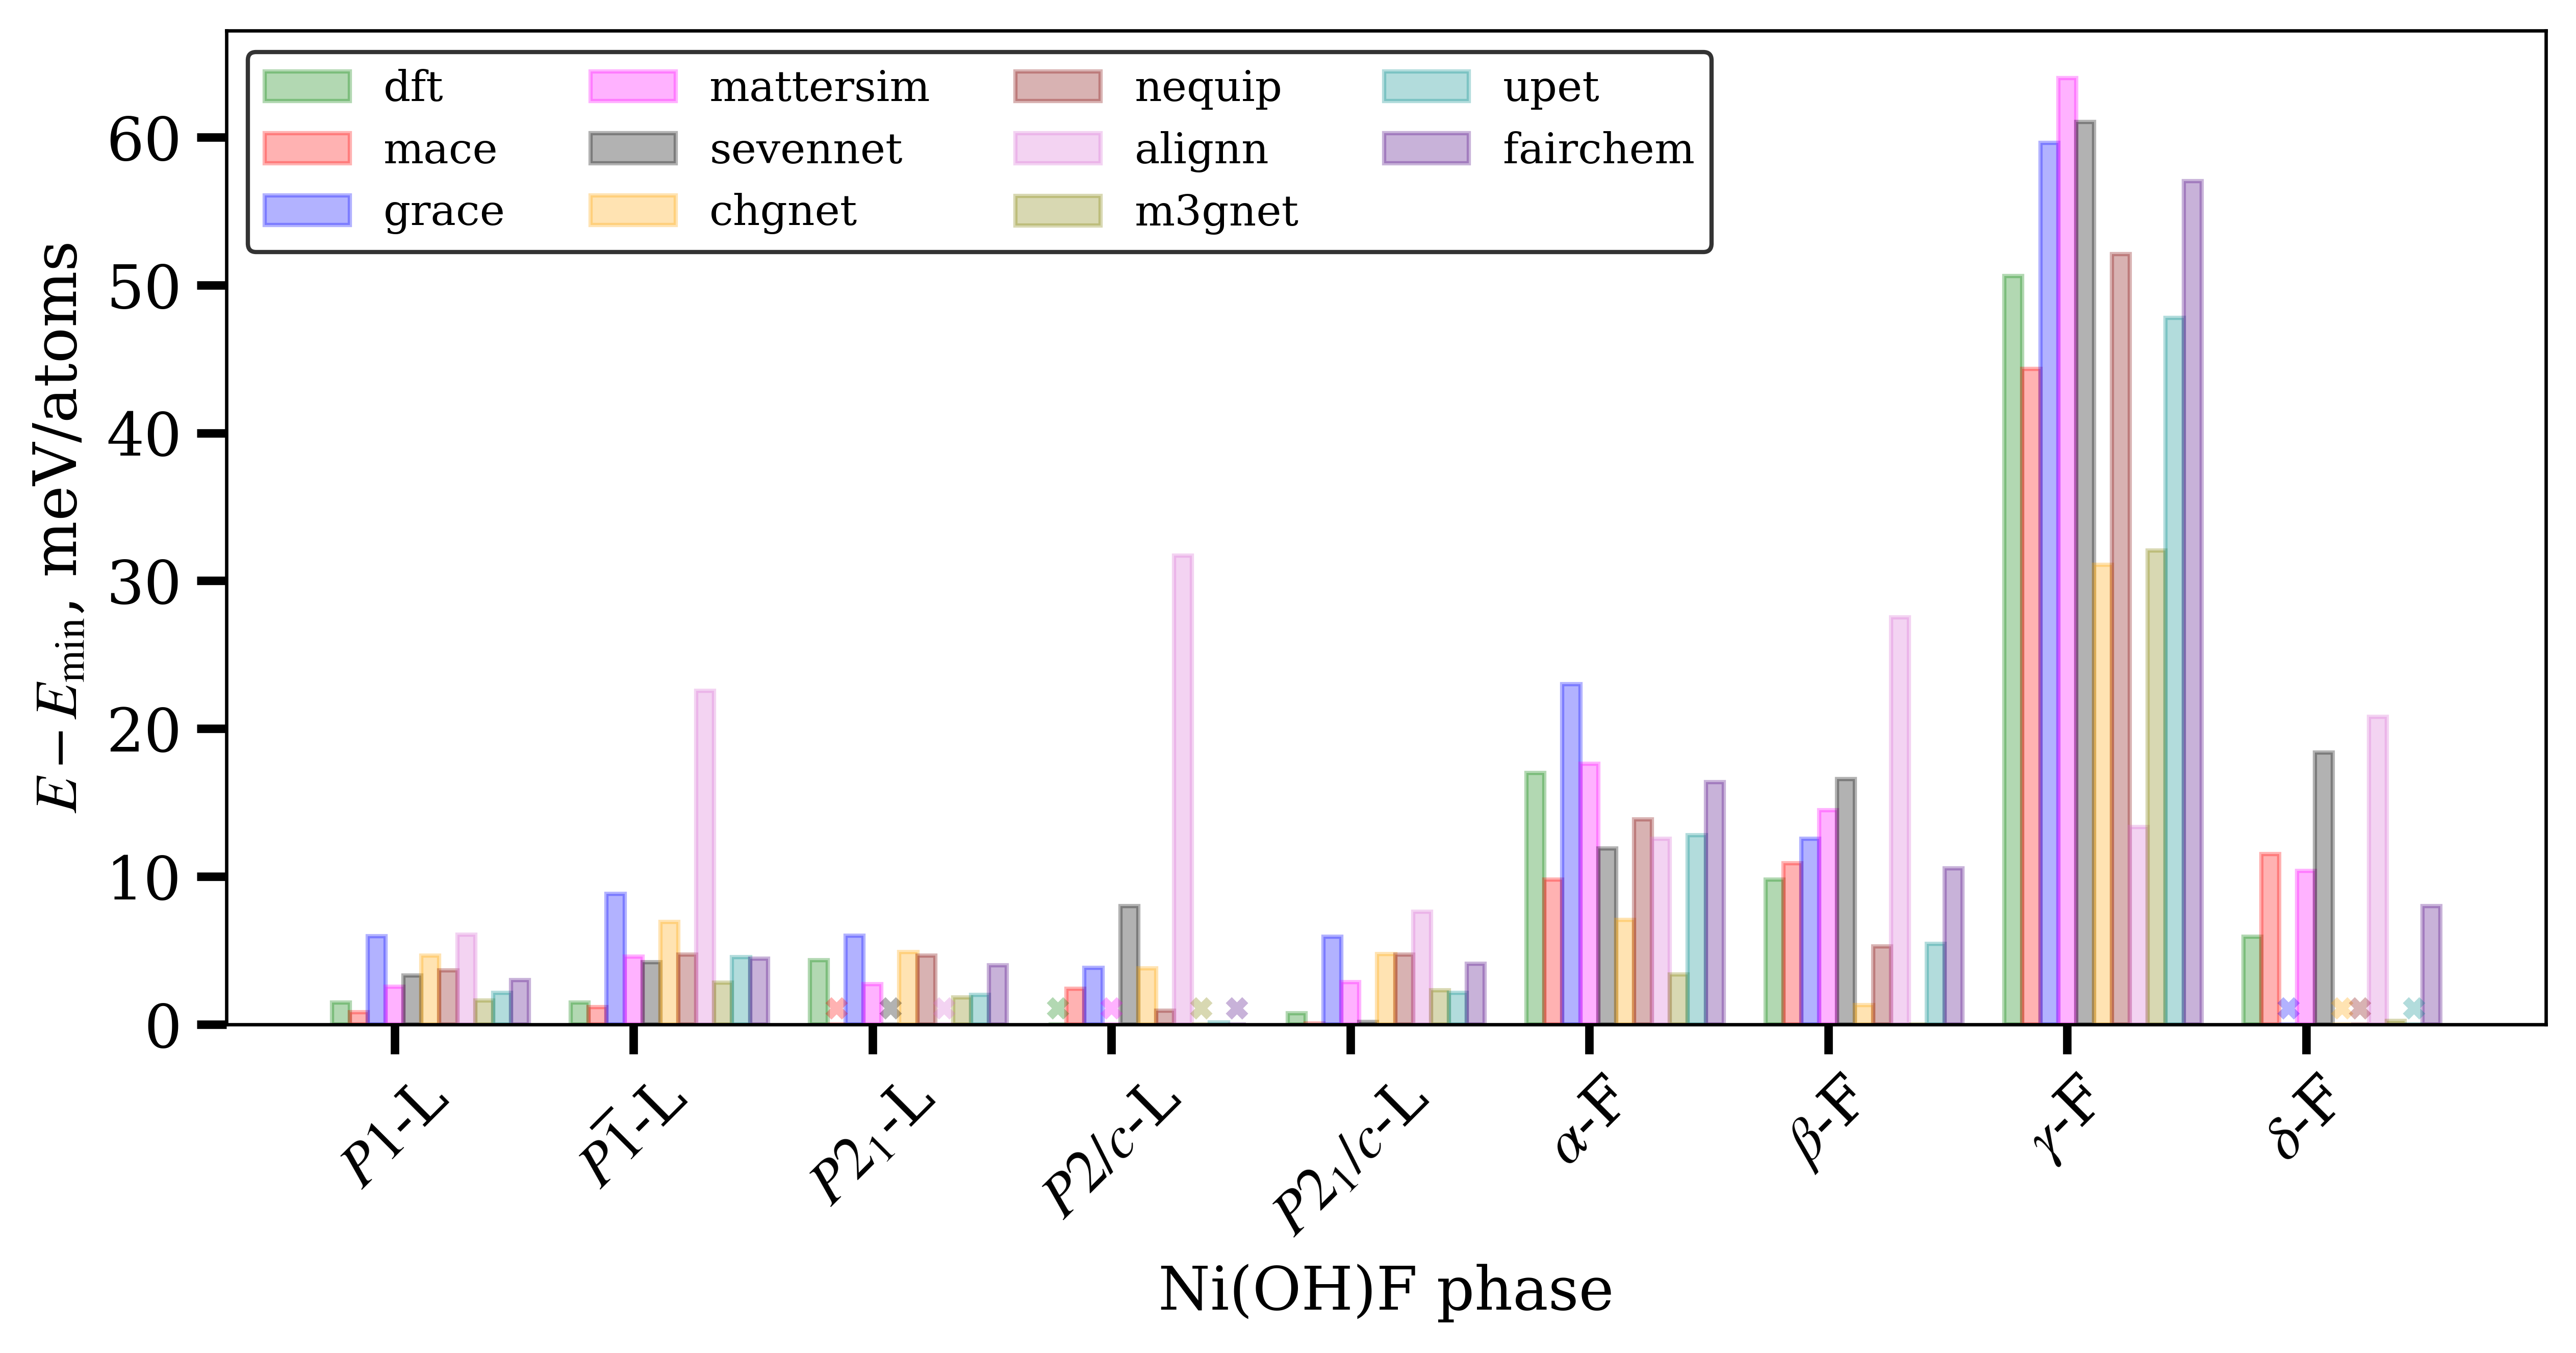

In [262]:
fontsize = 14
lw = 2.0

fig, ax = plt.subplots(1, 1, figsize=(9, 5), dpi=600)
plt.tight_layout()


# Add titles and labels
ax.set_ylabel(r'$E - E_{\mathrm{min}}$, meV/atoms', fontsize=fontsize)
ax.set_xlabel(r'Ni(OH)F phase', fontsize=fontsize)

ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.tick_params(axis='both', which='minor', labelsize=fontsize-2)
ax.yaxis.get_offset_text().set_fontsize(10)
ax.xaxis.set_tick_params(width=2, length=7)
ax.yaxis.set_tick_params(width=2, length=7)

length = len(names)
ax.set_xticks(range(length), names_plot, rotation=45)
idx_list = np.array(range(length))
shift = - (length // 2) + (length % 2)  # initial shift for bars
width = 0.075

for idx, (type_calc, val) in enumerate(data_all.items()):
    data_plot = data_all[type_calc]
    ax.bar(idx_list + width*(shift+idx), data_plot*1e3, width=width, color=colors[type_calc],
                           edgecolor=colors[type_calc], alpha=0.3, label=type_calc)

    # Add crosses for zero energy structures
    zero_mask = np.array(data_plot) == 0
    zero_positions = idx_list[zero_mask] + width*(shift+idx)
    if len(zero_positions) > 0:
        ax.scatter(zero_positions, np.zeros(len(zero_positions))+1.1, marker='x', s=15, 
                   color=colors[type_calc], linewidths=2, zorder=10, alpha=0.3, edgecolor=colors[type_calc])


ax.legend(fontsize=fontsize-4, edgecolor="black", ncols=length//2)

fig.tight_layout()

plt.show()

# fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/energies.png", bbox_inches='tight', dpi=450)
# fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/energies.pdf", bbox_inches='tight', dpi=450)

fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/energies.png", dpi=450)
fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/energies.pdf", dpi=450)




## Map of guesses

In [263]:
data_all

{'dft': array([0.00149, 0.0015 , 0.00436, 0.     , 0.00077, 0.017  , 0.0098 ,
        0.05061, 0.00595]),
 'mace': array([8.23886e-04, 1.17224e-03, 0.00000e+00, 2.43044e-03, 6.87032e-05,
        9.82166e-03, 1.08982e-02, 4.43316e-02, 1.15158e-02]),
 'grace': array([0.00596, 0.00884, 0.00602, 0.00383, 0.00596, 0.02302, 0.01255,
        0.05962, 0.     ]),
 'mattersim': array([0.00258, 0.00461, 0.00273, 0.     , 0.00289, 0.01763, 0.0145 ,
        0.064  , 0.0104 ]),
 'sevennet': array([0.00332, 0.00421, 0.     , 0.00803, 0.00018, 0.01191, 0.01659,
        0.06103, 0.01838]),
 'chgnet': array([0.00466, 0.00693, 0.0049 , 0.00379, 0.00476, 0.00706, 0.00132,
        0.03109, 0.     ]),
 'nequip': array([0.00365, 0.00472, 0.00465, 0.00095, 0.00474, 0.01386, 0.00529,
        0.0521 , 0.     ]),
 'alignn': array([0.00609, 0.02258, 0.     , 0.03172, 0.00764, 0.01257, 0.02752,
        0.01334, 0.02082]),
 'm3gnet': array([1.62287e-03, 2.84413e-03, 1.84444e-03, 0.00000e+00, 2.31162e-03,
        3.

In [264]:
list(data_all.keys())

['dft',
 'mace',
 'grace',
 'mattersim',
 'sevennet',
 'chgnet',
 'nequip',
 'alignn',
 'm3gnet',
 'upet',
 'fairchem']

In [265]:
names_calc = list(data_all.keys())

In [266]:
names_plot = [
    # "",
    '$P1$-L',
 '$P\\overline{1}$-L',
 '$P2_1$-L',
 '$P2/c$-L',
 '$P2_1/c$-L',
 '$\\alpha$-F',
 '$\\beta$-F',
 '$\\gamma$-F',
 '$\\delta$-F'
]



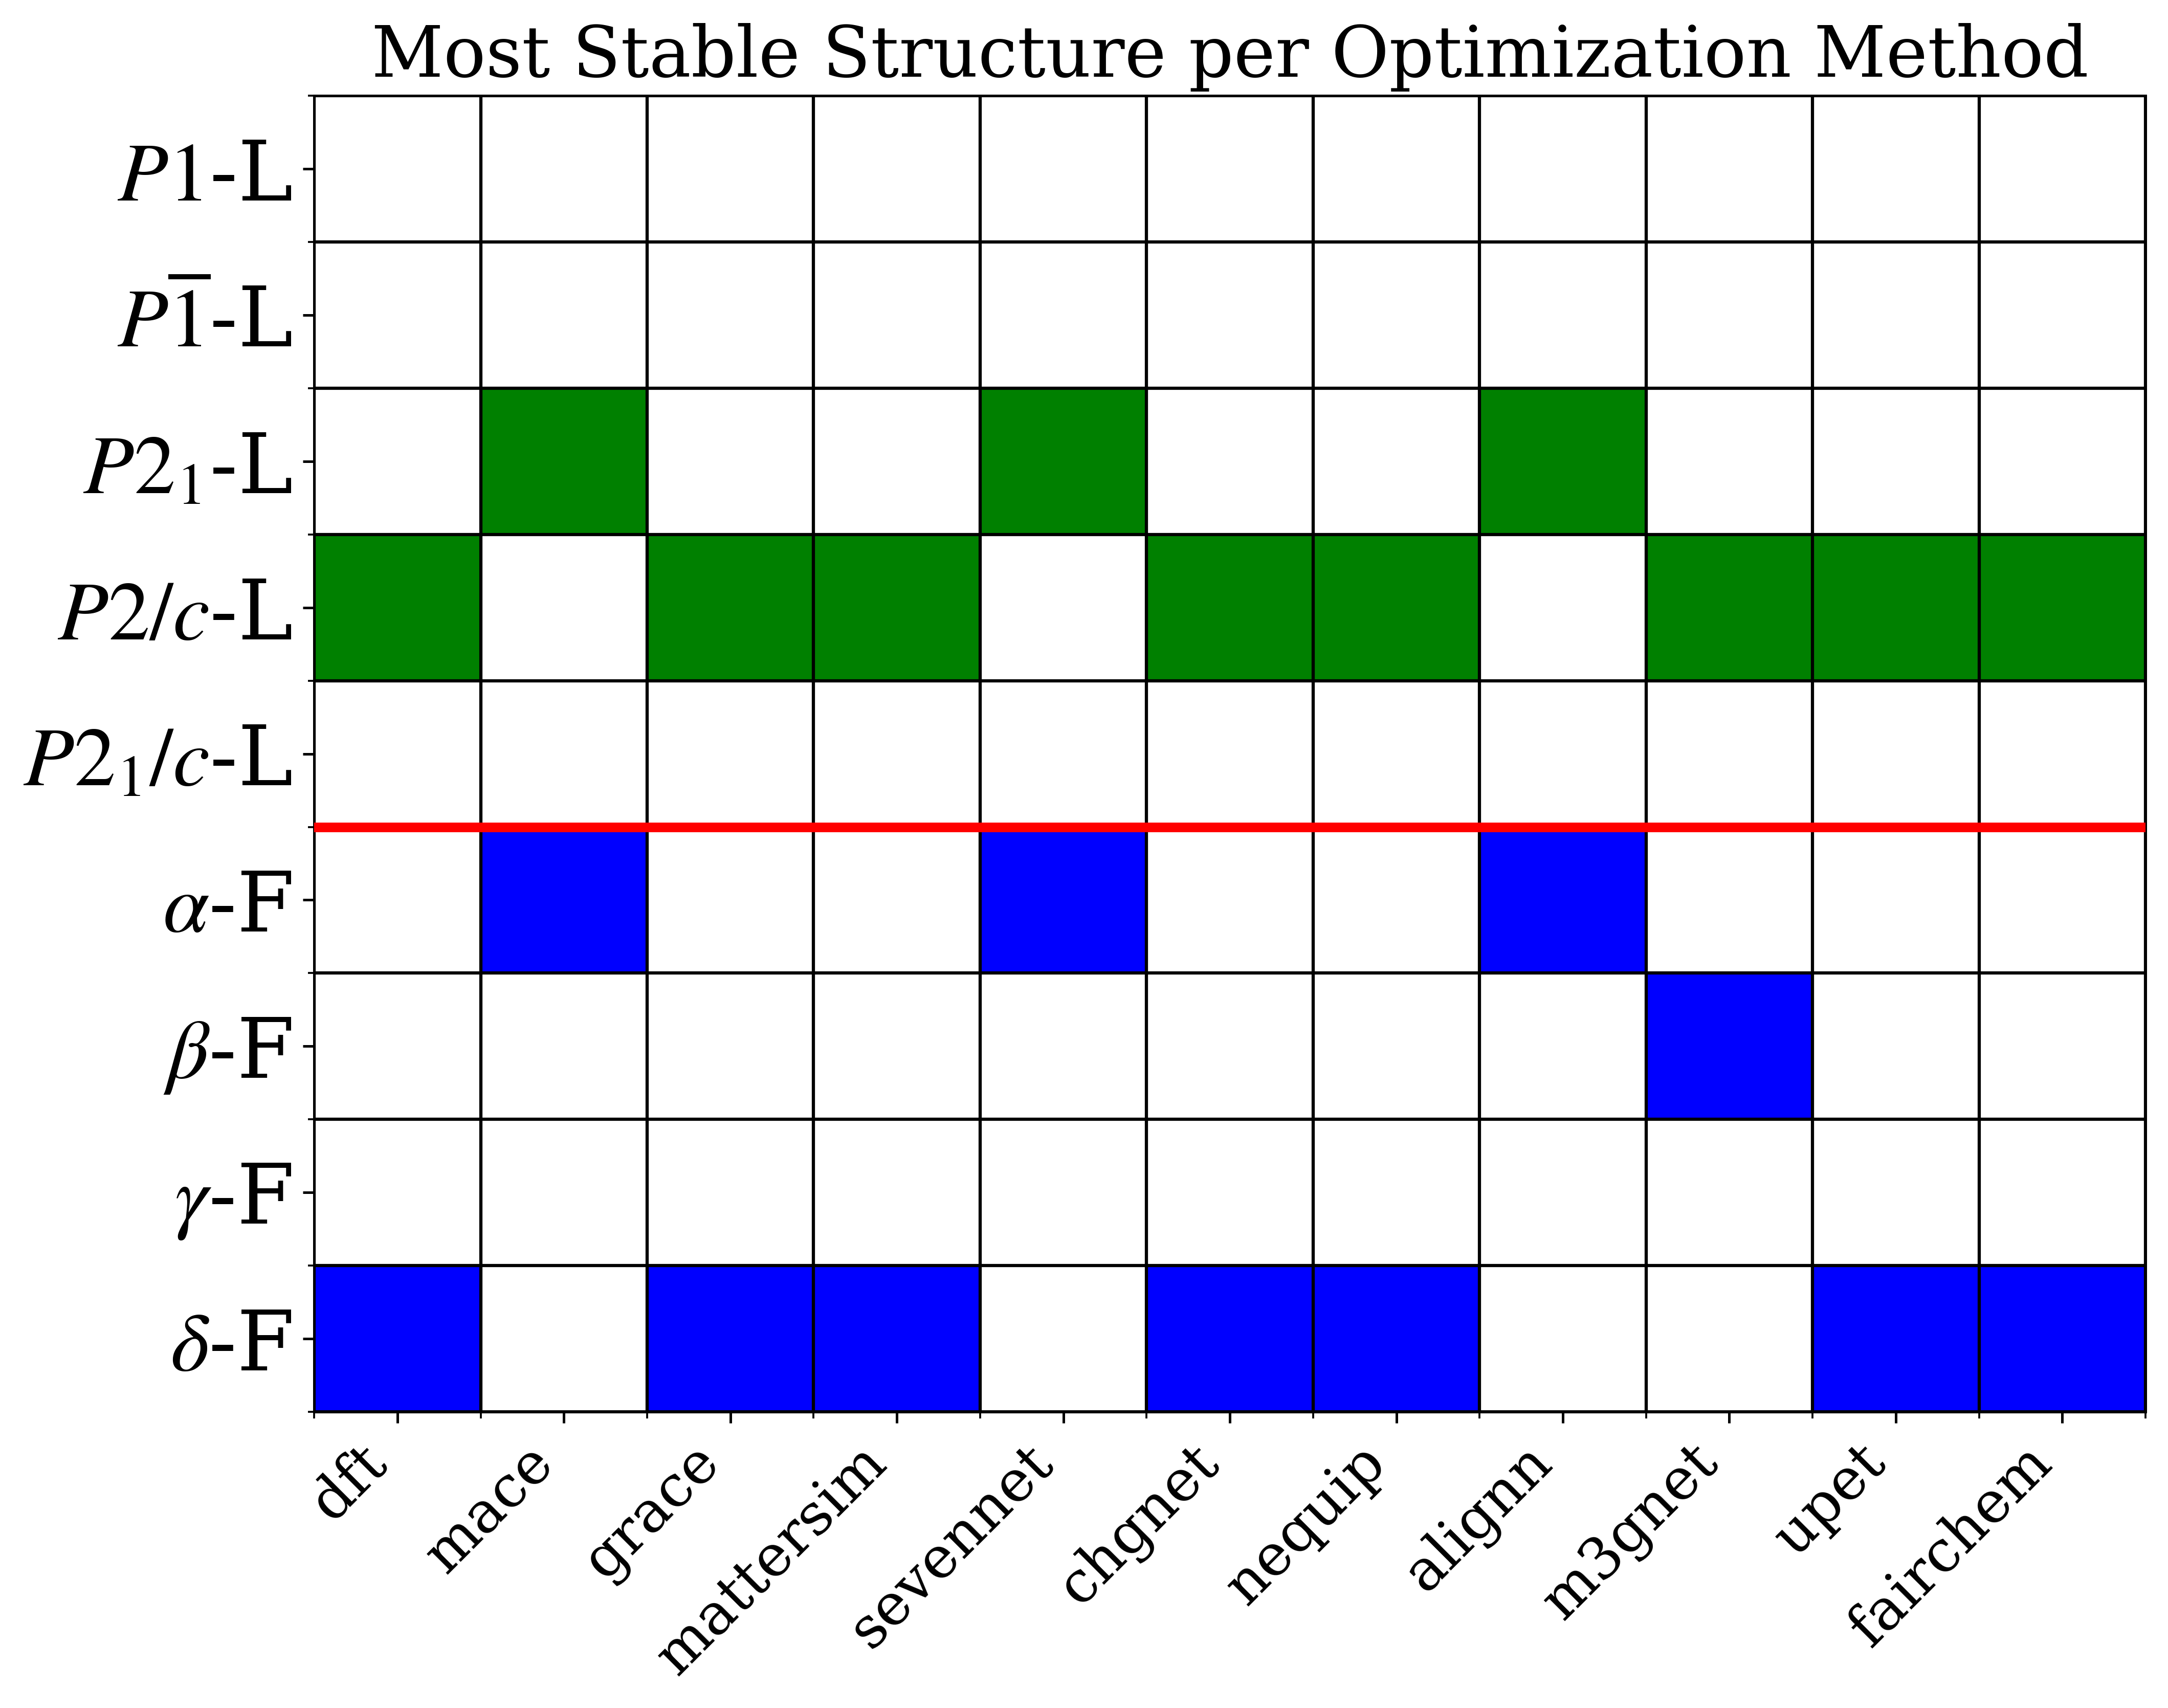

In [268]:
# Use CONSISTENT method names
methods = list(data_all.keys())  # 11 methods
n_methods = len(methods)  # Match your data

# ... your heatmap_data creation ...

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data[:, :n_methods], cmap=cmap, aspect='auto', vmin=0, vmax=2)  # Match columns

# Gridlines FIRST
ax.set_xticks(np.arange(n_methods + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(n_structures + 1) - 0.5, minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=1)

# REMOVED MaxNLocator - use exact ticks
ax.set_xticks(np.arange(n_methods))  # Exactly 11 ticks
ax.set_xticklabels(methods, fontsize=18, rotation=45, ha='right')  # Exactly 11 labels
ax.set_xticklabels(methods, fontsize=18, )  # Exactly 11 labels

ax.set_yticks(list(range(0,len(names_plot))))  # Exactly 11 ticks
ax.set_yticklabels(names_plot)
ax.axhline(y=4.5, color='red', linewidth=3, zorder=10)
ax.set_title('Most Stable Structure per Optimization Method', fontsize=22)

plt.tight_layout()

fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/guess_map.png", dpi=450)
fig.savefig("/home/a.burov/icys_2025/niohf/data/figures/guess_map.pdf", dpi=450)

plt.show()





### Atomic positions

In [208]:
st_names = ["layered_p1", "layered_p-1", "layered_p2c", "layered_p21", "layered_p21c", "alpha", "beta", "gamma", "delta"]

In [ ]:
path_dft = "/home/a.burov/icys_2025/niohf/optimized/dft/"


In [ ]:
# Dictionary of ALL potentials
potentials = {
    "sevennet": "/home/a.burov/icys_2025/niohf/optimized/sevenn/",
    "chgnet": "/home/a.burov/icys_2025/niohf/optimized/chgnet/",
    "alignn": "/home/a.burov/icys_2025/niohf/optimized/alignn/",
    "fairchem": "/home/a.burov/icys_2025/niohf/optimized/fairchem/",
    "grace": "/home/a.burov/icys_2025/niohf/optimized/grace/",
    "m3gnet": "/home/a.burov/icys_2025/niohf/optimized/m3gnet/",
    "mace": "/home/a.burov/icys_2025/niohf/optimized/mace/",
    "mattersim": "/home/a.burov/icys_2025/niohf/optimized/mattersim/",
    "nequip": "/home/a.burov/icys_2025/niohf/optimized/nequip/",
    "upet": "/home/a.burov/icys_2025/niohf/optimized/upet/",
    "tace": "/home/a.burov/icys_2025/niohf/optimized/tace/",
    "prophet": "/home/a.burov/icys_2025/niohf/optimized/prophet/",
}


In [ ]:
_available = {}
for pot_name, pot_path in potentials.items():
    missing_files = [
        name for name in st_names
        if not os.path.isfile(os.path.join(pot_path, name + ".vasp"))
    ]
    if missing_files:
        print(f"Skipping {pot_name}: missing {', '.join(missing_files)}")
        continue
    _available[pot_name] = pot_path
potentials = _available

diffs_dir = {}

for name in st_names:
    st_dft = smart_structure_read(path_dft + name + ".vasp")
    coords_dft = np.array(st_dft.xred)
    
    diffs_dir[name] = {}
    
    # Loop over ALL potentials
    for pot_name, pot_path in potentials.items():
        st_pot = smart_structure_read(pot_path + name + ".vasp")
        coords_pot = np.array(st_pot.xred)
        
        # Calculate fractional differences (minimum image)
        frac_diff = coords_pot - coords_dft
        frac_diff_minimg = frac_diff - np.round(frac_diff)
        per_atom_distances = np.sum(frac_diff_minimg**2, axis=1)**0.5
        
        diffs_dir[name][pot_name] = per_atom_distances
    
    print(f"Processed {name}: {list(potentials.keys())}")


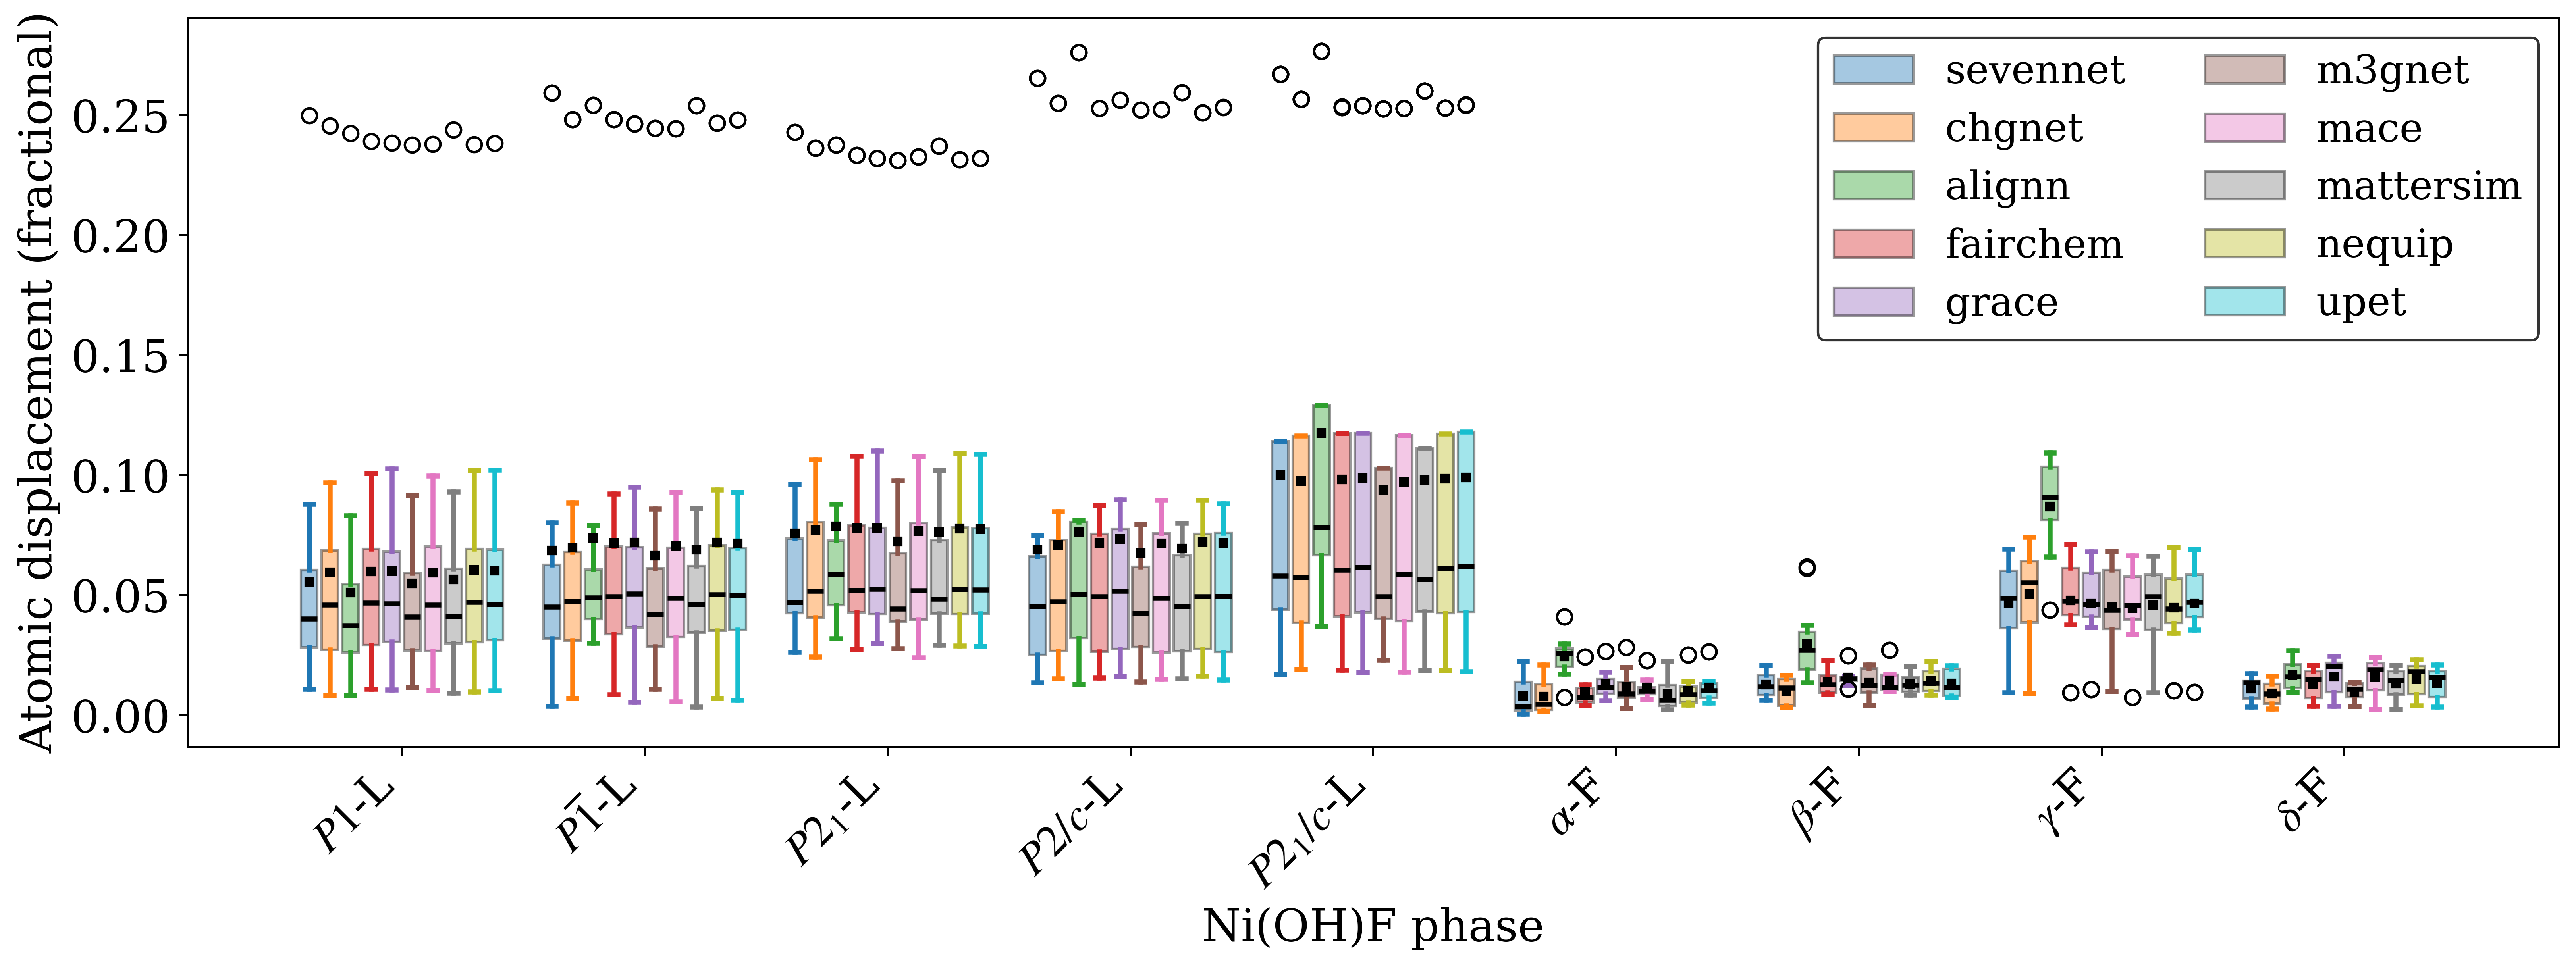

In [234]:
potentials_list = list(potentials.keys())  # ['sevennet', 'chgnet', 'alignn', ...]
n_pots = len(potentials_list)  # 10

fontsize = 18
lw = 2.0

phases = list(diffs_dir.keys())
data_all = {}  # Collect all data
for pot in potentials_list:
    data_all[pot] = [diffs_dir[p][pot] for p in phases]

x = np.arange(len(phases), dtype=float)
width = 0.85 / n_pots  # Dynamic width for 10 boxes

fig, ax = plt.subplots(figsize=(15, 6))  # Wider figure

# Colors for 10 potentials
colors = plt.cm.tab10(np.linspace(0, 1, n_pots))  # 10 distinct colors
box_plots = []

# Loop over ALL potentials
for i, pot_name in enumerate(potentials_list):
    bp = ax.boxplot(data_all[pot_name], 
                   positions=x + (i - n_pots/2 + 0.5) * width,  # Center groups
                   widths=width*0.8, patch_artist=True, showmeans=True)
    box_plots.append(bp)
    
    # Color styling
    box_color = colors[i]
    for b in bp['boxes']:
        b.set_facecolor(box_color)
        b.set_alpha(0.4)
    for part in ['caps', 'whiskers']:
        [item.set(color=box_color, linewidth=lw) for item in bp[part]]
    for median in bp['medians']:
        median.set(color="black", linewidth=lw)
    for mean in bp['means']:
        mean.set(marker='s', markeredgecolor="black", markerfacecolor="black", markersize=3)


# Formatting
ax.set_xticks(x)
ax.set_xticklabels(names_plot, rotation=45, ha='right')
ax.tick_params(axis='both', which='major', labelsize=fontsize)
ax.set_xlabel('Ni(OH)F phase', fontsize=fontsize)
ax.set_ylabel('Atomic displacement (fractional)', fontsize=fontsize)
ax.yaxis.get_offset_text().set_fontsize(10)

# Legend using first box of each
legend_elements = [bp['boxes'][0] for bp in box_plots]
ax.legend(legend_elements, potentials_list, loc=1, fontsize=fontsize-2, edgecolor='black', ncols=len(potentials.keys())//4)

plt.tight_layout()
plt.savefig("/home/a.burov/icys_2025/niohf/data/figures/atomic_pos_all.png", dpi=450, bbox_inches='tight')
plt.savefig("/home/a.burov/icys_2025/niohf/data/figures/atomic_pos_all.pdf", dpi=450, bbox_inches='tight')

plt.show()


### RMSE errors 

In [ ]:
potentials_list = list(potentials.keys())  # ['sevennet', 'chgnet', 'alignn', ...]
phases = list(diffs_dir.keys())
n_pots = len(potentials_list)
n_struct_types = 2  # layered, dispersed

# Split structures into layered (0-4) and dispersed (5-8)
layered_phases = phases[:5]
dispersed_phases = phases[5:]

# Calculate RMSE for each potential + structure type
rmse_data = {}
for pot in potentials_list:
    # RMSE = sqrt(mean(per_atom_distance**2))
    layered_rmse = [np.sqrt(np.mean(diffs_dir[p][pot]**2)) for p in layered_phases]
    dispersed_rmse = [np.sqrt(np.mean(diffs_dir[p][pot]**2)) for p in dispersed_phases]
    rmse_data[pot] = {'layered': np.mean(layered_rmse), 'dispersed': np.mean(dispersed_rmse)}

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(n_pots)
width = 0.35
fontsize = 18

# Layered bars (left)
layered_vals = [rmse_data[pot]['layered'] for pot in potentials_list]
c_layered, c_dispersed = series_colors(2)
bars1 = ax.bar(x - width/2, layered_vals, width, label='Layered', alpha=0.4, edgecolor=c_layered, color=c_layered)

# Dispersed bars (right)  
dispersed_vals = [rmse_data[pot]['dispersed'] for pot in potentials_list]
bars2 = ax.bar(x + width/2, dispersed_vals, width, label='Dispersed', alpha=0.4, edgecolor=c_dispersed, color=c_dispersed)

# Formatting
ax.set_xlabel('UMLIP type', fontsize=fontsize)
ax.set_ylabel('RMSE (fractional coordinates)', fontsize=fontsize)
ax.set_title('Atomic Position RMSE: Layered vs Dispersed Structures', fontsize=fontsize+2)
ax.set_xticks(x)
ax.set_xticklabels(potentials_list, rotation=45, ha='right')
ax.tick_params(axis='both', labelsize=fontsize)
ax.legend(fontsize=fontsize, loc=7)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
# for bar in bars1:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
#             f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
# for bar in bars2:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
#             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("/home/a.burov/icys_2025/niohf/data/figures/rmse_layered_dispersed.png", dpi=450, bbox_inches='tight')
plt.savefig("/home/a.burov/icys_2025/niohf/data/figures/rmse_layered_dispersed.pdf", dpi=450, bbox_inches='tight')
plt.show()




In [ ]:
write_database()

In [ ]:
# MP setup